In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

In [10]:
#  1. Data Collection & Preparation
def fetch_eth_data():
    """Fetch historical ETH/USDT data from Yahoo Finance"""
    eth = yf.download('ETH-USD', start='2020-01-01', end='2025-06-27', interval='1d')

    # Correctly access columns using the MultiIndex
    eth = eth[[('Open', 'ETH-USD'), ('High', 'ETH-USD'), ('Low', 'ETH-USD'), ('Close', 'ETH-USD'), ('Volume', 'ETH-USD')]]

    # Rename columns for easier access
    eth.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

    eth.reset_index(inplace=True)
    eth['Date'] = pd.to_datetime(eth['Date'])
    eth.set_index('Date', inplace=True)

    # Convert relevant columns to numeric (this should now work correctly)
    for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
        eth[col] = pd.to_numeric(eth[col], errors='coerce')

    # Handle missing values
    eth = eth.dropna()

    # Log returns for volatility analysis
    eth['Log_Close'] = np.log(eth['Close'])
    eth['Log_Returns'] = eth['Log_Close'].diff()

    return eth

In [11]:
def perform_eda(data):
    """Perform exploratory data analysis with visualizations"""
    # Ensure data is clean and indexed correctly
    data = data.copy()  # Avoid SettingWithCopyWarning
    data['Close'] = pd.to_numeric(data['Close'], errors='coerce')
    data['Volume'] = pd.to_numeric(data['Volume'], errors='coerce')
    data = data.dropna()  # Remove any rows with NaN after conversion

    plt.figure(figsize=(15, 10))

    # Price plot
    plt.subplot(2, 1, 1)
    x_values = data.index.astype('int64') // 10**9  # Convert DatetimeIndex to timestamps (seconds)
    y_values = data['Close'].values  # Ensure 1D array
    plt.plot(x_values, y_values, label='Close Price')

    rolling_mean = data['Close'].rolling(window=30, min_periods=1).mean().values
    plt.plot(x_values, rolling_mean, label='30-Day MA')
    plt.title('Ethereum (ETH/USDT) Price and 30-Day Moving Average')
    plt.xlabel('Timestamp (seconds since epoch)')
    plt.ylabel('Price (USDT)')
    plt.legend()

    # Volume plot
    plt.subplot(2, 1, 2)
    x_values_vol = data.index.astype('int64') // 10**9  # Consistent x-axis
    y_values_vol = data['Volume'].values
    plt.bar(x_values_vol, y_values_vol)
    plt.title('Trading Volume')
    plt.xlabel('Timestamp (seconds since epoch)')
    plt.ylabel('Volume')
    plt.tight_layout()
    plt.show()

    # Statistical summary
    print("\nStatistical Summary:")
    print(data[['Close', 'Volume', 'Log_Returns']].describe())

    # Volatility plot
    plt.figure(figsize=(10, 5))
    x_values_ret = data.index.astype('int64') // 10**9
    y_values_ret = data['Log_Returns'].values
    plt.plot(x_values_ret, y_values_ret, label='Log Returns')
    plt.title('Ethereum Log Returns (Volatility)')
    plt.xlabel('Timestamp (seconds since epoch)')
    plt.ylabel('Log Returns')
    plt.legend()
    plt.show()

    # Debug prints
    print("Data shape:", data.shape)
    print("Close values shape:", y_values.shape)
    print("Index shape:", x_values.shape)

In [12]:
# 3. Stationarity Testing
def test_stationarity(timeseries):
    """Perform ADF test for stationarity"""
    print("\nADF Test Results (Raw Data):")
    result = adfuller(timeseries.dropna())
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')

    # Test on differenced data
    diff_data = timeseries.diff().dropna()
    print("\nADF Test Results (Differenced Data):")
    result_diff = adfuller(diff_data)
    print(f'ADF Statistic: {result_diff[0]}')
    print(f'p-value: {result_diff[1]}')
    print('Critical Values:')
    for key, value in result_diff[4].items():
        print(f'\t{key}: {value}')

    # Plot differenced data
    plt.figure(figsize=(10, 5))
    plt.plot(diff_data.index, diff_data)
    plt.title('Differenced Log Close Price')
    plt.xlabel('Date')
    plt.ylabel('Differenced Log Price')
    plt.show()

In [13]:
# 4. ARIMA Model Development
def develop_arima_model(data, p=1, d=1, q=1):
    """Develop and fit ARIMA model"""
    # ACF and PACF plots
    plt.figure(figsize=(15, 5))
    plt.subplot(121)
    plot_acf(data['Log_Close'].diff().dropna(), lags=40, ax=plt.gca())
    plt.title('ACF Plot')
    plt.subplot(122)
    plot_pacf(data['Log_Close'].diff().dropna(), lags=40, ax=plt.gca())
    plt.title('PACF Plot')
    plt.tight_layout()
    plt.show()
    # Fit ARIMA model
    model = ARIMA(data['Log_Close'], order=(p, d, q))
    model_fit = model.fit()

    print("\nARIMA Model Summary:")
    print(model_fit.summary())

    return model_fit

In [14]:
# 5. Model Evaluation
def evaluate_model(model_fit, data, test_size=30):
    """Evaluate ARIMA model performance"""
    train_size = len(data) - test_size
    train, test = data['Log_Close'][:train_size], data['Log_Close'][train_size:]

    # Forecast
    forecast = model_fit.forecast(steps=test_size)

    # Calculate error metrics
    rmse = np.sqrt(mean_squared_error(test, forecast))
    mape = mean_absolute_percentage_error(test, forecast)

    print("\nModel Evaluation:")
    print(f'RMSE: {rmse:.4f}')
    print(f'MAPE: {mape:.4f}')

    # Plot residuals
    residuals = test - forecast
    plt.figure(figsize=(10, 5))
    plt.plot(residuals.index, residuals)
    plt.title('Residuals of ARIMA Model')
    plt.xlabel('Date')
    plt.ylabel('Residuals')
    plt.axhline(y=0, color='r', linestyle='--')
    plt.show()

    # Plot actual vs predicted
    plt.figure(figsize=(10, 5))
    plt.plot(test.index, np.exp(test), label='Actual Price')
    plt.plot(test.index, np.exp(forecast), label='Predicted Price')
    plt.title('Actual vs Predicted ETH/USDT Prices')
    plt.xlabel('Date')
    plt.ylabel('Price (USDT)')
    plt.legend()
    plt.show()

In [15]:
# 6. Forecasting & Visualization
def forecast_prices(model_fit, data, steps=30):
    """Generate and visualize 30-day price forecast"""
    forecast_result = model_fit.get_forecast(steps=steps)
    forecast_mean = forecast_result.predicted_mean
    conf_int = forecast_result.conf_int()

    # Create forecast index
    last_date = data.index[-1]
    forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=steps, freq='D')

    # Convert log prices back to regular prices
    forecast_mean_price = np.exp(forecast_mean)
    conf_int_lower = np.exp(conf_int['lower Log_Close'])
    conf_int_upper = np.exp(conf_int['upper Log_Close'])

    # Plot forecast
    plt.figure(figsize=(12, 6))
    plt.plot(data.index[-60:], np.exp(data['Log_Close'][-60:]), label='Historical Price')
    plt.plot(forecast_index, forecast_mean_price, label='Forecasted Price', color='orange')
    plt.fill_between(forecast_index, conf_int_lower, conf_int_upper, color='orange', alpha=0.2, label='95% Confidence Interval')
    plt.title('30-Day ETH/USDT Price Forecast')
    plt.xlabel('Date')
    plt.ylabel('Price (USDT)')
    plt.legend()
    plt.show()

    print("\nForecast Insights:")
    print(f"Mean forecasted price for day 30: ${forecast_mean_price[-1]:.2f}")
    print(f"95% Confidence Interval for day 30: ${conf_int_lower[-1]:.2f} - ${conf_int_upper[-1]:.2f}")


[*********************100%***********************]  1 of 1 completed


Data Source: Yahoo Finance
Date Range: 2020-01-01 00:00:00 to 2025-06-26 00:00:00
Preprocessing: Removed missing values, calculated log prices and returns


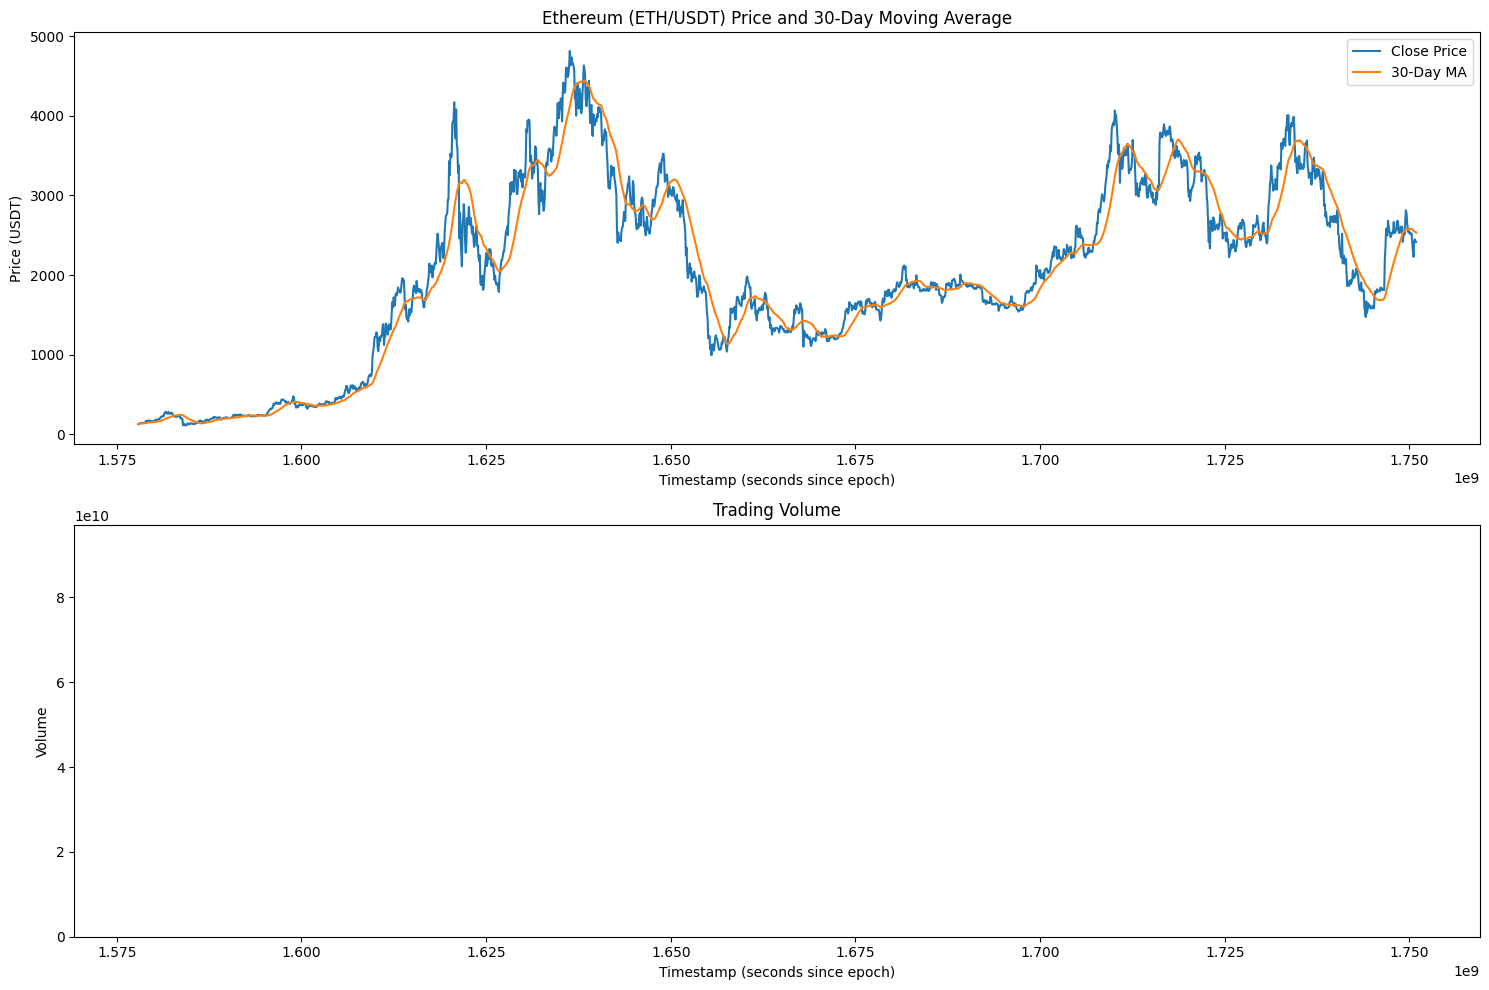


Statistical Summary:
             Close        Volume  Log_Returns
count  2003.000000  2.003000e+03  2003.000000
mean   2022.942572  1.716927e+10     0.001456
std    1114.769828  1.069505e+10     0.043971
min     110.605873  2.081626e+09    -0.550732
25%    1322.071594  9.893845e+09    -0.017731
50%    1905.491455  1.500590e+10     0.001220
75%    2856.268433  2.134746e+10     0.021753
max    4812.087402  9.245355e+10     0.230695


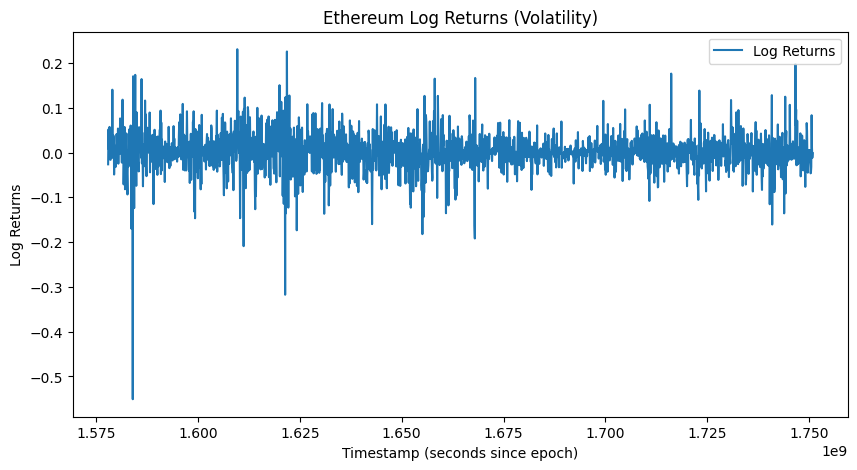

Data shape: (2003, 7)
Close values shape: (2003,)
Index shape: (2003,)

ADF Test Results (Raw Data):
ADF Statistic: -2.6873526024865813
p-value: 0.07625250754196516
Critical Values:
	1%: -3.43363537003345
	5%: -2.862991296796771
	10%: -2.5675426088474738

ADF Test Results (Differenced Data):
ADF Statistic: -13.428545195510228
p-value: 4.0564238610701095e-25
Critical Values:
	1%: -3.43363537003345
	5%: -2.862991296796771
	10%: -2.5675426088474738


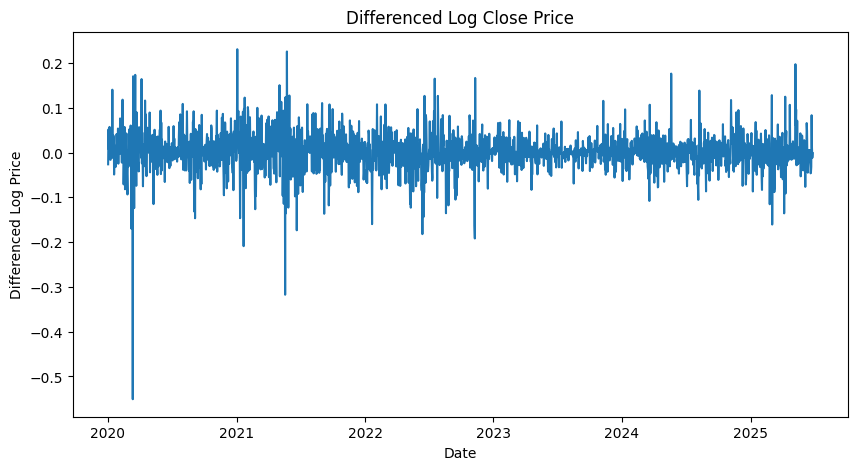

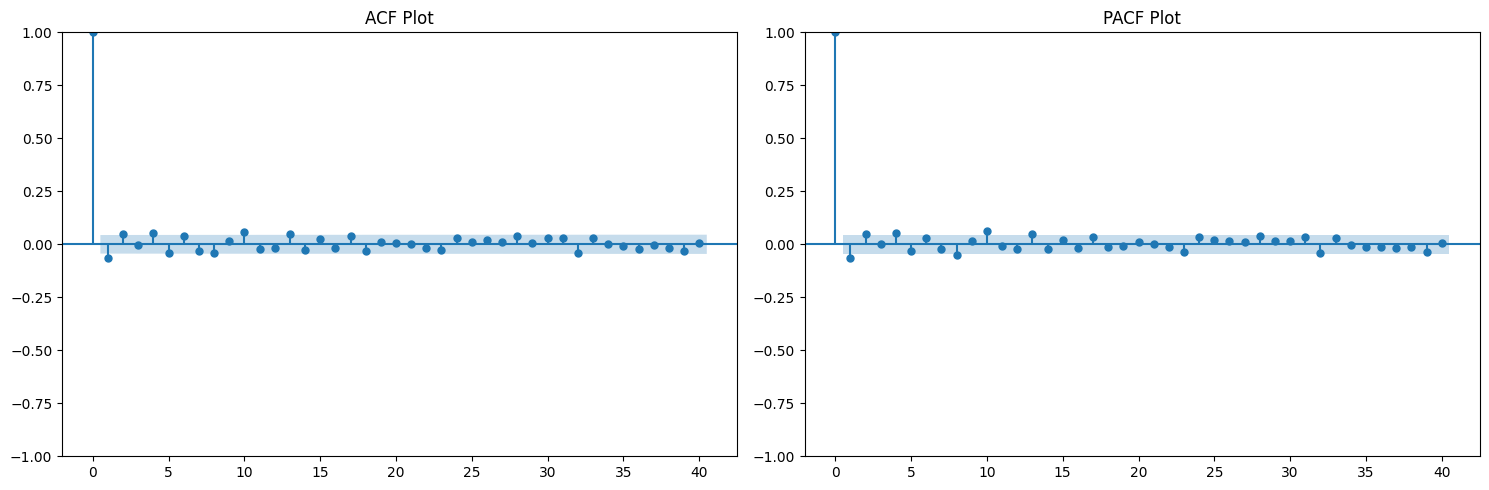


ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:              Log_Close   No. Observations:                 2004
Model:                 ARIMA(1, 1, 1)   Log Likelihood                3423.144
Date:                Sun, 29 Jun 2025   AIC                          -6840.288
Time:                        11:10:06   BIC                          -6823.481
Sample:                    01-01-2020   HQIC                         -6834.118
                         - 06-26-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7677      0.082     -9.331      0.000      -0.929      -0.606
ma.L1          0.7101      0.091      7.801      0.000       0.532       0.888
sigma2         0.0019   2.07e-

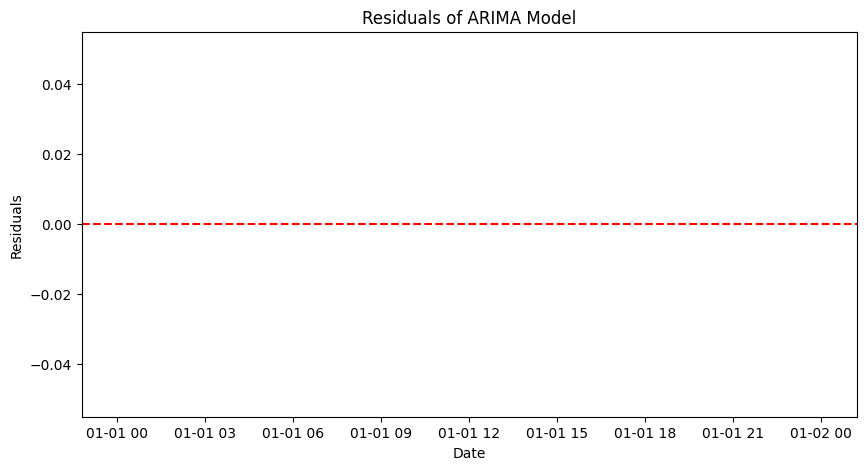

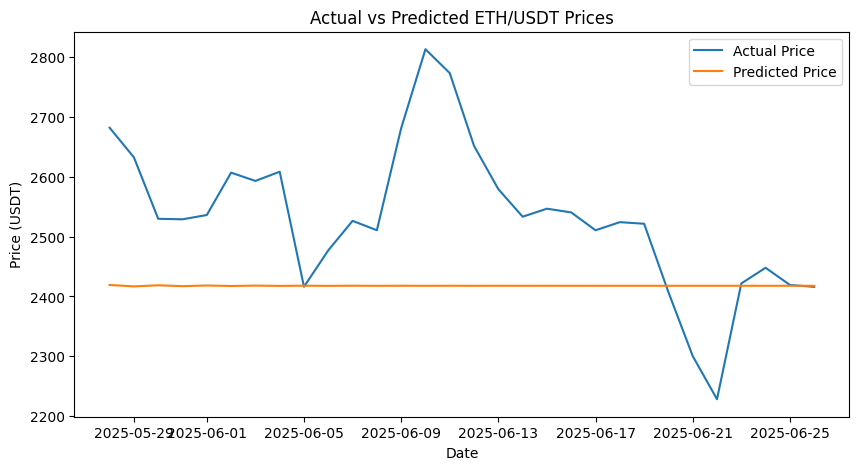

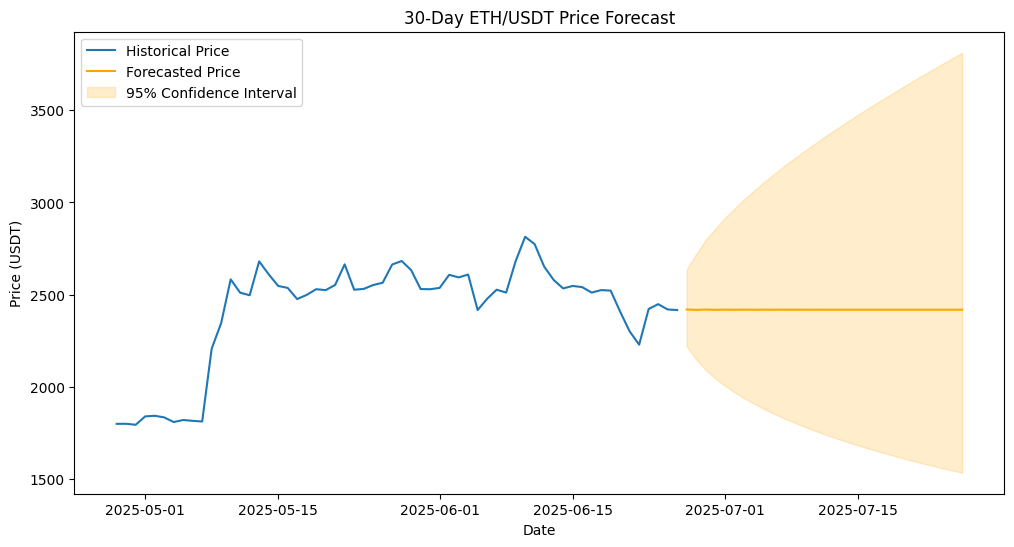


Forecast Insights:
Mean forecasted price for day 30: $2417.93
95% Confidence Interval for day 30: $1533.70 - $3811.95


In [8]:
# Main execution
def main():
    # Fetch and prepare data
    eth_data = fetch_eth_data()
    print("Data Source: Yahoo Finance")
    print(f"Date Range: {eth_data.index[0]} to {eth_data.index[-1]}")
    print("Preprocessing: Removed missing values, calculated log prices and returns")

    # Perform EDA
    perform_eda(eth_data)

    # Test stationarity
    test_stationarity(eth_data['Log_Close'])

    # Develop ARIMA model (using p=1, d=1, q=1 as a starting point based on ACF/PACF analysis)
    model_fit = develop_arima_model(eth_data, p=1, d=1, q=1)

    # Evaluate model
    evaluate_model(model_fit, eth_data)

    # Forecast prices
    forecast_prices(model_fit, eth_data)

if __name__ == "__main__":
    main()